# Improving Recommendation By Improving the Quality of Image Embeddings with SigLIP and Vertex AI

In the previous section, "**[02 - ResNet and Elasticsearch](https://github.com/carmel-wenga/Image-Based-Recommendation-System/tree/master/02%20-%20ResNet%20and%20Elasticsearch)**", we explored the semantic limitations of traditional Convolutional Neural Networks (CNNs). While CNN-based embeddings effectively capture low- and mid-level visual features—such as edges, textures, and colors—they often fail to encode the high-level global and semantic context that Vision-Language Models (VLMs) provide.

As demonstrated in [this medium story](https://pub.towardsai.net/building-an-image-based-recommendation-system-and-search-engine-with-deep-learning-and-4bb96c4d9a64), recommendations relying solely on CNN embeddings can include semantically irrelevant items. To mitigate this in Part 02, we implemented an additional filtering layer using **Filtered $k$-NN** searches in Elasticsearch.

**The VLM Advantage**

A more robust approach to improving recommendation quality is leveraging Vision-Language Models for embedding extraction. Unlike standard CNNs, VLMs are pretrained on massive datasets of image-text pairs, allowing them to bridge the gap between visual pixels and conceptual meaning.

In this notebook, we will explore how to enhance retrieval precision using two state-of-the-art VLM approaches:

* *SigLIP (Sigmoid Loss for Language-Image Pre-training)*
* *Google Vertex AI Multimodal Embedding API*

**Prerequisites**

Before proceeding, please ensure you have the following configured:

* Elasticsearch Instance: A running instance (e.g., ```http://localhost:9200```).
* Index Mapping: An ```items``` index with the mapping defined in Part 02 of this repository.
* Data Initialization: To follow along, please run the first ten cells of [notebook](https://github.com/carmel-wenga/Image-Based-Recommendation-System/blob/master/02%20-%20ResNet%20and%20Elasticsearch/src/IBRS%20and%20Search%20Engine.ipynb) from Part 02. This ensures your Elasticsearch instance is populated with the correctly indexed documents.

In [1]:
from elasticsearch import Elasticsearch
from src.settings import DATASET_DIR, MODEL_FIELD_MAPPING
from src.utils import unzip_dataset
import os

es = Elasticsearch("http://localhost:9200")

# unzip dataset if not yet done
unzip_dataset()

[INFO] Dataset already unzipped


## 1. Embedding Extraction with SigLIP

Defining an abstract base class for embedding extraction, and concrete implementations for SigLIP and latter on for Vertex AI.

In [2]:
from abc import ABC, abstractmethod
from typing import List
import numpy as np
from PIL import Image
import torch
from transformers import AutoProcessor, AutoModel


class ImageEmbeddingExtractor(ABC):
    @abstractmethod
    def extract_embeddings(self, image_paths: List[str]) -> np.ndarray:
        """Extract embeddings for a batch of image paths."""
        pass


class SigLIPEmbeddingExtractor(ImageEmbeddingExtractor):
    def __init__(self, model_name="google/siglip-base-patch16-224"):
        self.processor = AutoProcessor.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name)
        self.model.eval()

    def extract_embeddings(self, image_paths: List[str]) -> np.ndarray:
        images = [Image.open(path).convert("RGB") for path in image_paths]
        inputs = self.processor(images=images, return_tensors="pt")
        with torch.no_grad():
            embeddings = self.model.get_image_features(**inputs)
            embeddings = embeddings.pooler_output
        return embeddings.detach().cpu().numpy()

Similariy, the ResNet50 Embedding Extractor can be defined as follows:

```python
class ResNet50EmbeddingExtractor(ImageEmbeddingExtractor):
    def __init__():
        base_model = resnet50.ResNet50(weights='imagenet')
        model = Model(inputs=base_model.inputs, outputs=base_model.get_layer('avg_pool').output)

    def extract_embeddings(self, image_paths: List[str]):
        images = [load_image(path) for path in image_paths]
        batch = np.stack(images, axis=0)
        return self.model.predict(batch, verbose=0)
```

### Test Embedding Extraction with SigLIP

In [3]:
# create an instance of the SigLIP Embedding Extractor
siglip_extractor = SigLIPEmbeddingExtractor()

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

In [4]:
# set test image, you can use any image paths
test_paths = ["/home/projects/IBRS/Image-Based-Recommendation-System/etc/dataset/img1.jpg"]

# extract embeddings of the test image and display its shape
embeddings = siglip_extractor.extract_embeddings(test_paths)
np.shape(embeddings)

(1, 768)

## 2. Extract All Embeddings and Update ES

Before extracting embeddings, we need to update the elasticsearch's index mapping and add a new attribute that will be used to story the SigLIP vector.

1. Update Index Mapping
2. Extract Embeddings and Store in ES

### 2.1. Update the Elasticsearch Index Mapping

The existing index, the ***items*** from Elasticsearch as the following mapping:
```json
mapping = {
  "mappings": {
    "properties": {
      "ID": {
        "type": "integer"
      },
      "title": {
        "type": "text",
        "fields": {
          "keyword": {
            "type": "keyword"
          }
        }
      },
      "slug": {
        "type": "text",
        "fields": {
          "keyword": {
            "type": "keyword"
          }
        }
      },
      "category": {
        "type": "keyword"
      },
      "imPath": {
        "type": "keyword"
      },
      "image_features": {
        "type": "dense_vector",
        "dims": 2048,
        "index": True,
        "similarity": "cosine"
      }
    }
  }
}
```

In order to store new embeddings vectors, the SigLIP embeddings vectors in this case, we need to update the ```items``` index. We will add a ```image_features_siglip``` attribute as follows:

In [5]:
from src.elastic import update_index_mapping

siglip_field = MODEL_FIELD_MAPPING.get("siglip")

# define the new attribute for the siglip embedding vector
new_mapping_properties = {
    "properties": {
        siglip_field: { 
            "type": "dense_vector",
            "dims": 768,
            "index": True,
            "similarity": "cosine"
        }
    }
}

update_index_mapping(es, index_name="items", body=new_mapping_properties)

[INFO] Index 'items' mapping updated.


In [6]:
# check that the mapping has been updated
es.indices.get_mapping(index="items")

ObjectApiResponse({'items': {'mappings': {'properties': {'ID': {'type': 'integer'}, 'category': {'type': 'keyword'}, 'imPath': {'type': 'keyword'}, 'image_features': {'type': 'dense_vector', 'dims': 2048, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'image_features_siglip': {'type': 'dense_vector', 'dims': 768, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'siglip_features': {'type': 'dense_vector', 'dims': 768, 'index': True, 'similarity': 'cosine', 'index_options': {'type': 'bbq_hnsw', 'm': 16, 'ef_construction': 100, 'rescore_vector': {'oversample': 3.0}}}, 'slug': {'type': 'text', 'fields': {'keyword': {'type': 'keyword'}}}, 'title': {'type': 'text', 'fields': {'keyword': {'type': 'keyword'}}}}}}})

### 2.2. Extract and Store All Embeddings

In [7]:
from src.elastic import bulk_update_embeddings

def extract_embeddings_and_update_es(es, embedding_extractor: ImageEmbeddingExtractor, model: str = "resnet", index_name: str = "items", batch_size=128):
    # query ES to get all the image path
    query = {
        "size": batch_size,
        "query": {
            "bool": {
                "must_not": {
                    "exists": {"field": MODEL_FIELD_MAPPING.get(model)}
                }
            }
        }
    }
    
    response = es.search(index=index_name, body=query, scroll="5m")
    scroll_id = response["_scroll_id"]
    
    while True:
        items = response["hits"]["hits"]
    
        if not items:
            break
    
        # batch processing
        paths = [os.path.join(DATASET_DIR, item["_source"]["imPath"]) for item in items]
        embeddings = embedding_extractor.extract_embeddings(paths)
        bulk_update_embeddings(es, index_name, items, embeddings, model)
    
        # continue scrolling
        response = es.scroll(scroll_id=scroll_id, scroll="5m")
    
    print("DONE: all embeddings updated.")

In [8]:
# extract the SigLIP image embeddings and update the Elasticsearch index
extract_embeddings_and_update_es(
    es=es, 
    embedding_extractor=siglip_extractor, 
    model="siglip"
)

DONE: all embeddings updated.


## 3. Perform Recommendations

This section not only shows the resulting recommandation, but allow emphasize the recommendation quality when using SigLIP compared to ResNet.

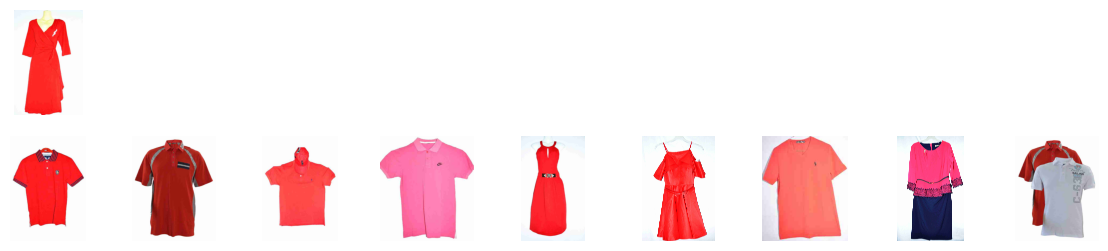

In [9]:
from src.utils import make_recommendations

# recommendation with resnet embeddings
make_recommendations(es=es, item_id=1087, model="resnet")

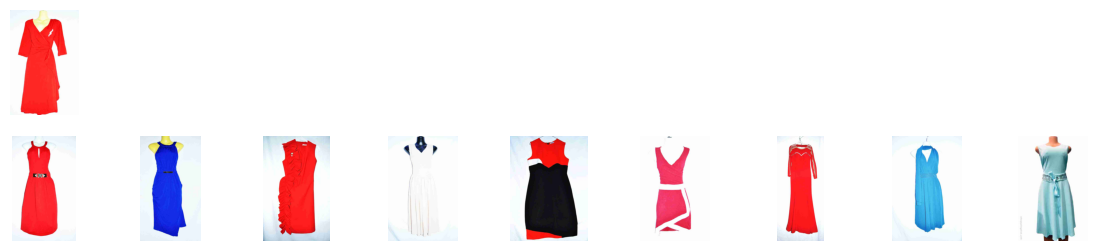

In [10]:
# recommendation with siglip embeddings
make_recommendations(es=es, item_id=1087, model="siglip")

## 3. Visual Search Engine with SigLIP

In [11]:
from src.elastic import visual_search
from src.utils import display_knn

img_paths = [
    os.path.join(DATASET_DIR, 'img1.jpg'), # woman shoes
    os.path.join(DATASET_DIR, 'img2.png')  # woman afritude
]

img_vectors = siglip_extractor.extract_embeddings(img_paths)

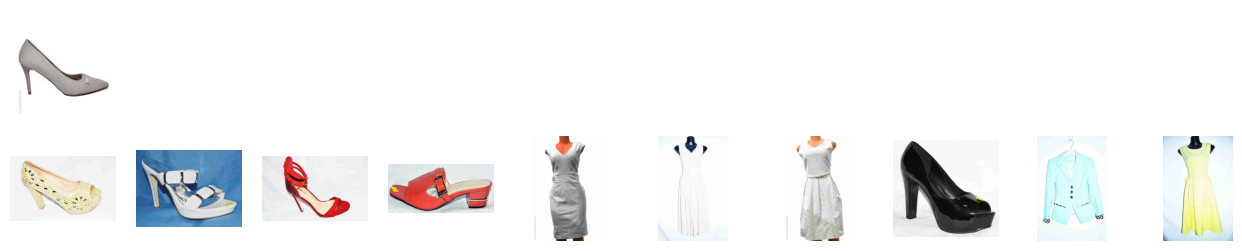

In [12]:
knn_results = visual_search(es=es, src_vector=img_vectors[0], model="siglip")
display_knn(knn_items=knn_results, src_img_path=img_paths[0])

The search result when using ResNet50 was the following:

![image](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*al33ZJd0hjYsxH8bNkgm9w.png)

**Observations**:

1. **Superior Semantic Understanding**: SigLIP provides significantly higher-quality results. Unlike ResNet50, it successfully filters out irrelevant categories such as men’s footwear and children’s items.
2. **Cross-Category Retrieval**: A key differentiator is SigLIP’s ability to retrieve items outside the immediate "shoes" category, such as dresses and blazers. This suggests two sophisticated search behaviors:
    * *Style Matching*: The model identifies these items as belonging to a similar aesthetic or "women’s fashion" cluster.
    * *Predictive Styling*: The results can be interpreted as a "Complete the Look" feature, identifying dresses that would naturally be paired with the requested shoes.

**To sum up**, while ResNet50 appears to focus on low-level visual features (like basic shapes or soles), SigLIP captures the high-level intent of the query image.
  

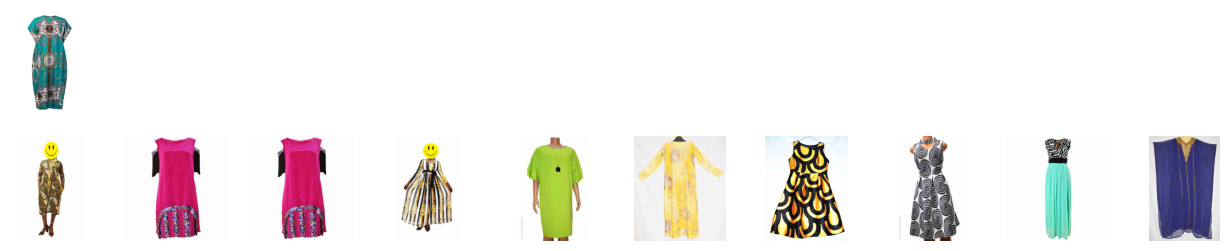

In [13]:
# second example
knn2_results = visual_search(es=es, src_vector=img_vectors[1], model="siglip")
display_knn(knn_items=knn2_results, src_img_path=img_paths[1])

### Author
Carmel WENGA, Data & ML Engineer
- [Medium](https://medium.com/@carmelwenga)
- [LinkedIn](https://www.linkedin.com/in/carmel-christian-wenga-871876178/)